# Amazon Delivery Time Analysis

## Project Overview

This project analyzes Amazon delivery operations using Python for data cleaning, exploratory data analysis (EDA), feature engineering, statistical analysis, and business insights.

### Objectives

- Clean and preprocess the dataset
- Explore delivery performance
- Analyze traffic impact
- Analyze weather impact
- Perform statistical testing
- Generate business recommendations

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_theme(style="whitegrid")

# 1. Data Loading

Load the Amazon Delivery dataset and preview the first records.

In [2]:
df = pd.read_csv("amazon_delivery.csv")
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,19/03/2022,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,25/03/2022,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,19/03/2022,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,05/04/2022,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,26/03/2022,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


## Dataset Dimensions

Check the number of rows and columns in the dataset.

In [3]:
df.shape

(43739, 16)

## Dataset Information

Inspect data types and identify missing values.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  str    
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  str    
 8   Order_Time       43739 non-null  str    
 9   Pickup_Time      43739 non-null  str    
 10  Weather          43648 non-null  str    
 11  Traffic          43739 non-null  str    
 12  Vehicle          43739 non-null  str    
 13  Area             43739 non-null  str    
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 5.3 MB


In [5]:
df.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics

Generate summary statistics for numerical features.

In [7]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


# 2. Data Cleaning

Identify missing values in the dataset.

In [8]:
df.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [9]:
df["Agent_Rating"] = (
    df.groupby("Category")["Agent_Rating"]
      .transform(lambda x: x.fillna(x.median()))
)

In [10]:
df["Weather"] = (
    df.groupby("Category")["Weather"]
      .transform(lambda x: x.fillna(x.mode()[0]))
)

### Verify Missing Values

Confirm that all missing values have been handled successfully.

In [11]:
df.isnull().sum()

Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

### Check Categorical Variables

Review category distributions before building visual analysis.

In [12]:
df["Weather"].value_counts()

Weather
Fog           7454
Stormy        7407
Cloudy        7309
Sandstorms    7259
Windy         7227
Sunny         7083
Name: count, dtype: int64

In [13]:
df["Traffic"].value_counts()

Traffic
Low        14999
Jam        13725
Medium     10628
High        4296
NaN           91
Name: count, dtype: int64

In [14]:
df["Vehicle"].value_counts()

Vehicle
motorcycle     25527
scooter        14639
van             3558
bicycle           15
Name: count, dtype: int64

In [15]:
df["Area"].value_counts()

Area
Metropolitian     32698
Urban              9751
Other              1138
Semi-Urban          152
Name: count, dtype: int64

In [16]:
df["Category"].value_counts()

Category
Electronics     2849
Books           2824
Jewelry         2802
Toys            2781
Skincare        2772
Snacks          2770
Outdoors        2747
Apparel         2726
Sports          2719
Grocery         2691
Pet Supplies    2690
Home            2685
Cosmetics       2677
Kitchen         2673
Clothing        2667
Shoes           2666
Name: count, dtype: int64

### Final Missing Values Check

Confirm that missing values are removed before exploratory analysis.

In [17]:
df.isnull().sum()

Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

# 3. Exploratory Data Analysis

### Delivery Time by Traffic

Analyze how different traffic conditions affect delivery time.

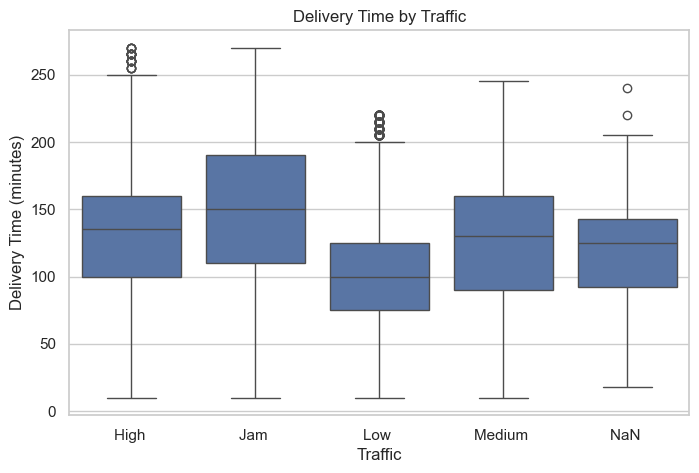

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Traffic", y="Delivery_Time")
plt.title("Delivery Time by Traffic")
plt.xlabel("Traffic")
plt.ylabel("Delivery Time (minutes)")
plt.show()

In [19]:
df.groupby("Traffic")["Delivery_Time"].mean().sort_values()

Traffic
Low        101.354557
NaN        120.670330
Medium     126.839669
High       129.424115
Jam        147.758980
Name: Delivery_Time, dtype: float64

### Delivery Time by Weather

Evaluate how weather conditions influence delivery time.

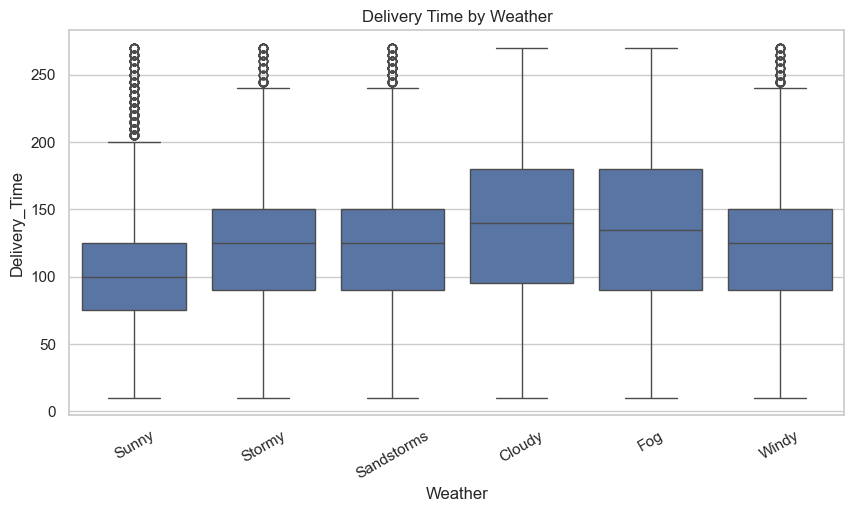

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Weather", y="Delivery_Time")
plt.title("Delivery Time by Weather")
plt.xticks(rotation=30)
plt.show()

In [21]:
df.groupby("Weather")["Delivery_Time"].mean().sort_values()

Weather
Sunny         103.682338
Stormy        123.206291
Sandstorms    123.215043
Windy         123.669157
Fog           136.509659
Cloudy        138.262279
Name: Delivery_Time, dtype: float64

### Delivery Time by Vehicle

Compare delivery performance across different vehicle types.

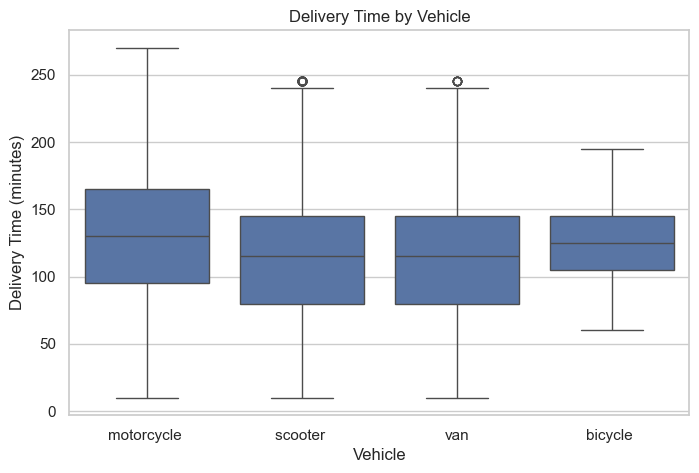

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Vehicle", y="Delivery_Time")
plt.title("Delivery Time by Vehicle")
plt.xlabel("Vehicle")
plt.ylabel("Delivery Time (minutes)")
plt.show()

In [23]:
df.groupby("Vehicle")["Delivery_Time"].agg(["mean", "median", "count"]).sort_values("mean")

,mean,median,count
Vehicle,,,
van,116.137156,115.0,3558
scooter,116.361637,115.0,14639
bicycle,127.000000,125.0,15
motorcycle,131.026325,130.0,25527


### Number of Deliveries by Vehicle

Analyze the distribution of deliveries across vehicle types.

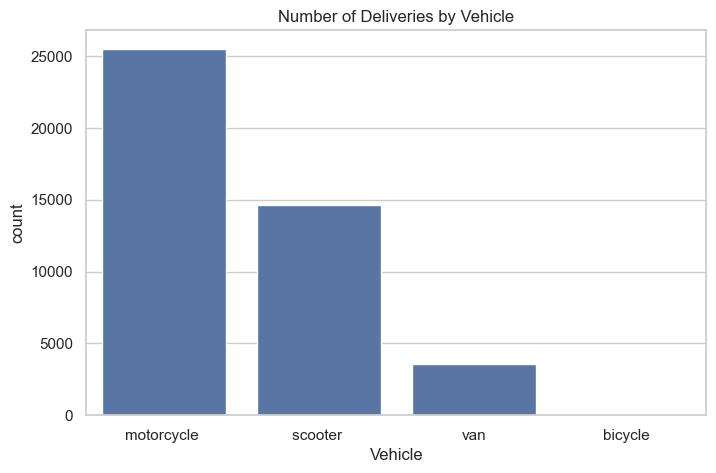

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Vehicle")
plt.title("Number of Deliveries by Vehicle")
plt.show()

### Delivery Time by Area

Compare delivery time across different delivery areas.

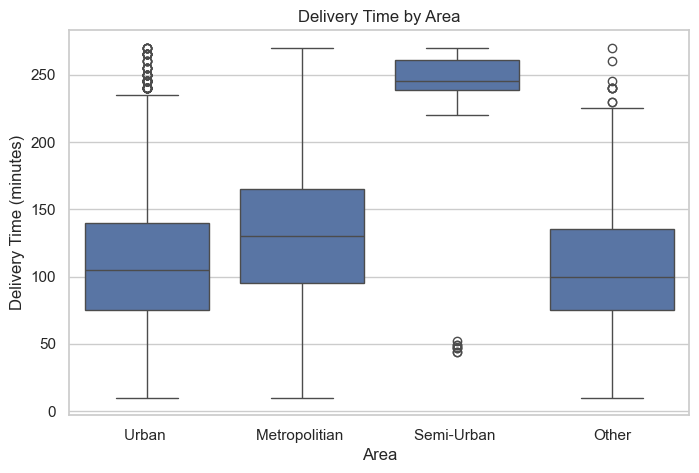

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Area", y="Delivery_Time")
plt.title("Delivery Time by Area")
plt.xlabel("Area")
plt.ylabel("Delivery Time (minutes)")
plt.show()

In [26]:
df.groupby("Area")["Delivery_Time"].agg(["mean", "median", "count"]).sort_values("mean")

,mean,median,count
Area,,,
Other,104.464851,100.0,1138
Urban,109.434520,105.0,9751
Metropolitian,129.702459,130.0,32698
Semi-Urban,238.552632,245.0,152


### Agent Rating vs Delivery Time

Explore whether courier ratings are associated with delivery time.

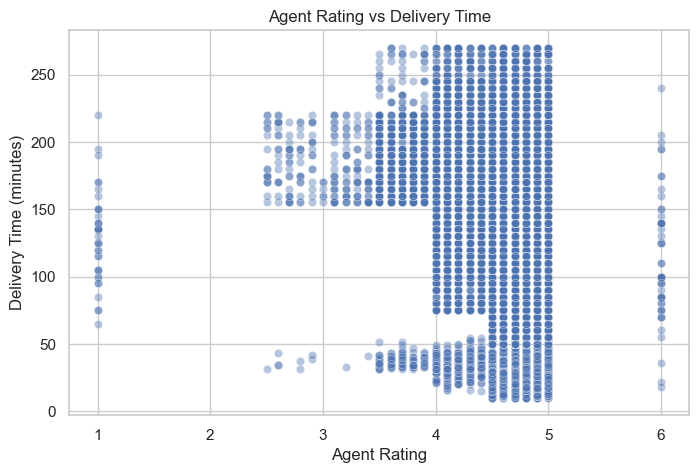

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Agent_Rating", y="Delivery_Time", alpha=0.4)
plt.title("Agent Rating vs Delivery Time")
plt.xlabel("Agent Rating")
plt.ylabel("Delivery Time (minutes)")
plt.show()

In [28]:
df[["Agent_Rating", "Delivery_Time"]].corr()

,Agent_Rating,Delivery_Time
Agent_Rating,1.000000,-0.289855
Delivery_Time,-0.289855,1.000000


### Correlation Heatmap

Visualize correlations between numerical features to identify potential relationships.

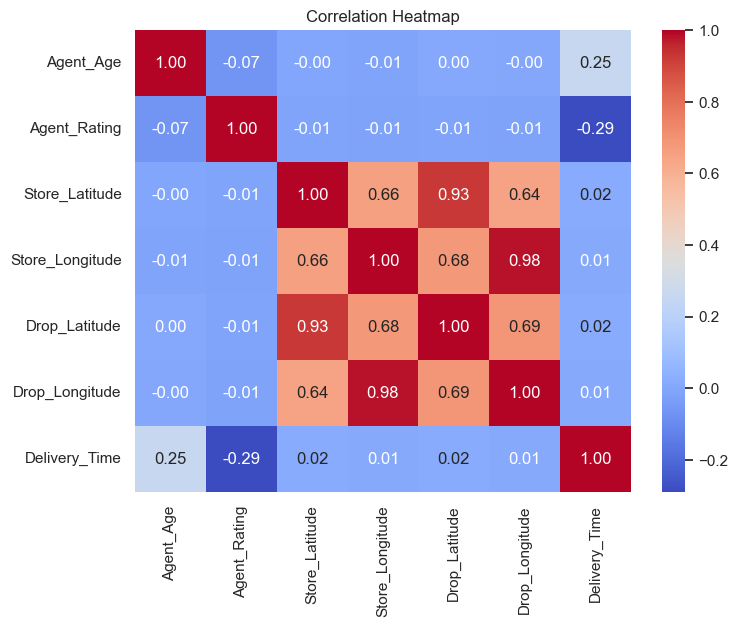

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [30]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d/%m/%Y")

In [31]:
df["Order_Time"] = pd.to_datetime(
    df["Order_Time"],
    format="%H:%M:%S",
    errors="coerce"
)

In [32]:
df["Pickup_Time"] = pd.to_datetime(df["Pickup_Time"], format="%H:%M:%S")

In [33]:
df[df["Order_Time"].isnull()]

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaT,1900-01-01 17:20:00,Fog,NaN,motorcycle,Urban,75,Home
2779,oilg311747812,15,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaT,1900-01-01 20:30:00,Fog,NaN,scooter,Metropolitian,145,Kitchen
2825,pbox816153129,15,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaT,1900-01-01 22:10:00,Sunny,NaN,bicycle,Metropolitian,100,Clothing
3438,nzsa056960624,50,6.0,-12.970324,-77.645748,13.010324,77.685748,2022-03-13,NaT,1900-01-01 12:30:00,Stormy,NaN,van,Urban,125,Cosmetics
4514,eids248121351,50,6.0,-17.451976,-78.385883,17.561976,78.495883,2022-04-04,NaT,1900-01-01 23:20:00,Stormy,NaN,bicycle,Metropolitian,135,Jewelry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40359,lasg907081524,50,6.0,22.751234,75.889490,22.781234,75.919490,2022-03-17,NaT,1900-01-01 20:40:00,Windy,NaN,scooter,Metropolitian,140,Apparel
41088,wgdm794380305,50,6.0,-12.939496,77.625999,12.949496,77.635999,2022-03-19,NaT,1900-01-01 09:40:00,Cloudy,NaN,van,Metropolitian,95,Books
42598,llox673359294,15,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-14,NaT,1900-01-01 17:40:00,Stormy,NaN,scooter,Metropolitian,170,Jewelry
43053,ifig993965994,15,1.0,13.086438,80.220672,13.216439,80.350672,2022-03-18,NaT,1900-01-01 18:00:00,Stormy,NaN,van,Urban,130,Jewelry


In [34]:
df[df["Order_Time"].isnull()].shape

(91, 16)

In [35]:
df = df.dropna(subset=["Order_Time"]).reset_index(drop=True)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43648 entries, 0 to 43647
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         43648 non-null  str           
 1   Agent_Age        43648 non-null  int64         
 2   Agent_Rating     43648 non-null  float64       
 3   Store_Latitude   43648 non-null  float64       
 4   Store_Longitude  43648 non-null  float64       
 5   Drop_Latitude    43648 non-null  float64       
 6   Drop_Longitude   43648 non-null  float64       
 7   Order_Date       43648 non-null  datetime64[us]
 8   Order_Time       43648 non-null  datetime64[us]
 9   Pickup_Time      43648 non-null  datetime64[us]
 10  Weather          43648 non-null  str           
 11  Traffic          43648 non-null  str           
 12  Vehicle          43648 non-null  str           
 13  Area             43648 non-null  str           
 14  Delivery_Time    43648 non-null  int64         
 

In [37]:
df["Day_of_Week"]=df["Order_Date"].dt.day_name()

In [38]:
df["Minth"]=df["Order_Date"].dt.month_name()

In [39]:
df = df.rename(columns={"Minth": "Month"})

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43648 entries, 0 to 43647
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         43648 non-null  str           
 1   Agent_Age        43648 non-null  int64         
 2   Agent_Rating     43648 non-null  float64       
 3   Store_Latitude   43648 non-null  float64       
 4   Store_Longitude  43648 non-null  float64       
 5   Drop_Latitude    43648 non-null  float64       
 6   Drop_Longitude   43648 non-null  float64       
 7   Order_Date       43648 non-null  datetime64[us]
 8   Order_Time       43648 non-null  datetime64[us]
 9   Pickup_Time      43648 non-null  datetime64[us]
 10  Weather          43648 non-null  str           
 11  Traffic          43648 non-null  str           
 12  Vehicle          43648 non-null  str           
 13  Area             43648 non-null  str           
 14  Delivery_Time    43648 non-null  int64         
 

## Feature Engineering

Create new features from date and time columns, including order hour, preparation time, day of the week, and month. Handle negative preparation times caused by orders crossing midnight.

In [41]:
df["Order_Hour"] = df["Order_Time"].dt.hour

In [42]:
df["Preparation_Time"]=(df["Pickup_Time"] - df["Order_Time"]).dt.total_seconds() / 60

In [43]:
df[["Day_of_Week","Month","Order_Hour","Preparation_Time"]].head()

,Day_of_Week,Month,Order_Hour,Preparation_Time
0,Saturday,March,11,15.0
1,Friday,March,19,5.0
2,Saturday,March,8,15.0
3,Tuesday,April,18,10.0
4,Saturday,March,13,15.0


In [44]:
df["Preparation_Time"].describe()

count    43648.000000
mean       -17.325422
std        196.243803
min      -1435.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Preparation_Time, dtype: float64

In [45]:
df.loc[df["Preparation_Time"] < 0,"Preparation_Time"]  += 24*60

In [46]:
df["Preparation_Time"].describe()

count    43648.000000
mean         9.991294
std          4.086680
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Preparation_Time, dtype: float64

In [47]:
df[df["Preparation_Time"]<0]

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Day_of_Week,Month,Order_Hour,Preparation_Time


## Distance Feature Engineering

Calculate the geographical distance between the store and the customer's location using the Haversine formula. This feature helps analyze how delivery distance affects delivery time.

In [48]:
from math import radians,sin,cos,sqrt,atan2

In [49]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [50]:
df["Distance_km"] = df.apply(
    lambda row: haversine(
        row["Store_Latitude"],
        row["Store_Longitude"],
        row["Drop_Latitude"],
        row["Drop_Longitude"]
    ),
    axis=1
)

In [51]:
df["Distance_km"].describe()

count    43648.000000
mean        27.255432
std        303.815765
min          1.465067
25%          4.663432
50%          9.220419
75%         13.682165
max       6884.726399
Name: Distance_km, dtype: float64

In [52]:
df[["Distance_km", "Delivery_Time"]].head()

,Distance_km,Delivery_Time
0,3.025149,120
1,20.183530,165
2,1.552758,130
3,7.790401,105
4,6.210138,150


In [53]:
df[df["Distance_km"] > 100].shape

(156, 21)

In [54]:
df[df["Distance_km"] > 100][[
    "Store_Latitude",
    "Store_Longitude",
    "Drop_Latitude",
    "Drop_Longitude",
    "Distance_km"
]].head(10)

,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Distance_km
90,-27.163303,78.057044,27.233303,78.127044,6048.631240
275,-27.165108,78.015053,27.225108,78.075053,6047.919478
1045,-15.546594,73.760431,15.606594,73.820431,3464.082720
1705,-23.230791,77.437020,23.250791,77.457020,5168.516553
1893,-22.539129,88.365507,22.549129,88.375507,5013.585658
2015,-15.157944,73.950889,15.197944,73.990889,3375.423601
2052,-9.959778,76.296106,9.969778,76.306106,2216.065794
2112,-15.513150,73.783460,15.563150,73.833460,3455.531261
2202,-15.576683,73.755750,15.646683,73.825750,3471.888400
2525,-30.902872,75.826808,30.972872,75.896808,6880.272782


In [55]:
df = df[df["Distance_km"] <= 100].reset_index(drop=True)

In [56]:
df["Distance_km"].describe()

count    43492.000000
mean         9.733464
std          5.604463
min          1.465067
25%          4.663412
50%          9.220178
75%         13.681416
max         20.969489
Name: Distance_km, dtype: float64

In [57]:
df.shape

(43492, 21)

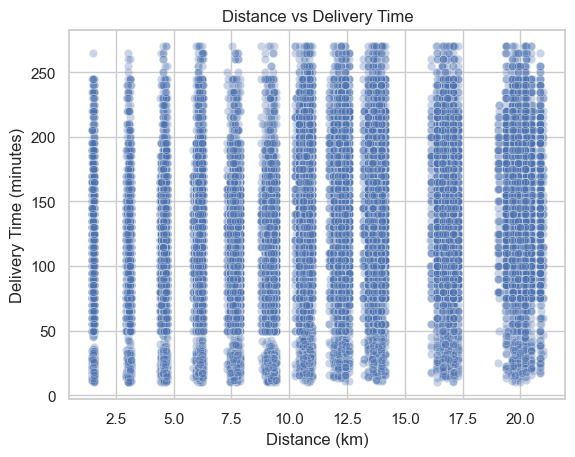

In [58]:
sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Delivery_Time",
    alpha=0.3
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

### Observation

After removing unrealistic GPS coordinates, delivery distances range from approximately 1.5 km to 21 km. The scatter plot suggests a positive relationship between travel distance and delivery time, although other factors such as traffic and weather also influence delivery performance.

In [59]:
df[["Distance_km", "Delivery_Time"]].corr()

,Distance_km,Delivery_Time
Distance_km,1.000000,0.277413
Delivery_Time,0.277413,1.000000


## Relationship Between Distance and Delivery Time

This section examines whether delivery distance is associated with delivery time. Pearson correlation is calculated, followed by a regression plot to visualize the overall trend between these two variables.

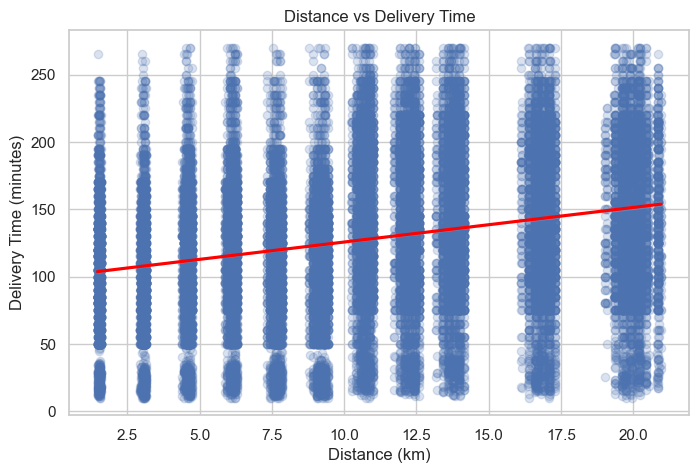

In [60]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Distance_km",
    y="Delivery_Time",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

### Observation

The correlation coefficient (0.277) indicates a weak positive relationship between travel distance and delivery time. The regression line confirms that longer trips generally require more time, although traffic, weather, and operational conditions also contribute to delivery duration.

## Final Dataset Verification

Before proceeding to the final analysis, the dataset is verified to ensure that all preprocessing steps were completed successfully. This includes checking the dataset dimensions, data types, and confirming that no missing values remain.

In [61]:
df.shape

(43492, 21)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43492 entries, 0 to 43491
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          43492 non-null  str           
 1   Agent_Age         43492 non-null  int64         
 2   Agent_Rating      43492 non-null  float64       
 3   Store_Latitude    43492 non-null  float64       
 4   Store_Longitude   43492 non-null  float64       
 5   Drop_Latitude     43492 non-null  float64       
 6   Drop_Longitude    43492 non-null  float64       
 7   Order_Date        43492 non-null  datetime64[us]
 8   Order_Time        43492 non-null  datetime64[us]
 9   Pickup_Time       43492 non-null  datetime64[us]
 10  Weather           43492 non-null  str           
 11  Traffic           43492 non-null  str           
 12  Vehicle           43492 non-null  str           
 13  Area              43492 non-null  str           
 14  Delivery_Time     43492 non-null 

In [63]:
df.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating        0
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather             0
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
Day_of_Week         0
Month               0
Order_Hour          0
Preparation_Time    0
Distance_km         0
dtype: int64

### Observation

The final dataset contains no missing values. All variables have appropriate data types, and the newly engineered features were successfully added. The dataset is now clean and ready for statistical analysis and predictive modeling.

## Order Distribution by Hour

To understand customer ordering behavior throughout the day, we examine how orders are distributed across different hours. This helps identify peak demand periods and operational workload patterns.

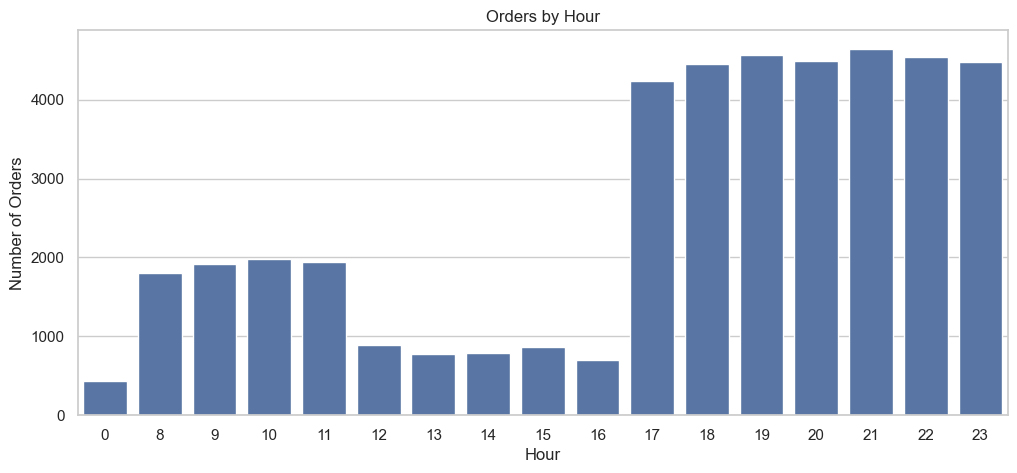

In [64]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Order_Hour"
)

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.show()

### Observation

Order volume is unevenly distributed throughout the day. The highest number of orders occurs during the evening hours (approximately 17:00–23:00), while demand is considerably lower during midday and around midnight. This suggests that customer activity is concentrated in the evening, likely reflecting common meal ordering patterns.

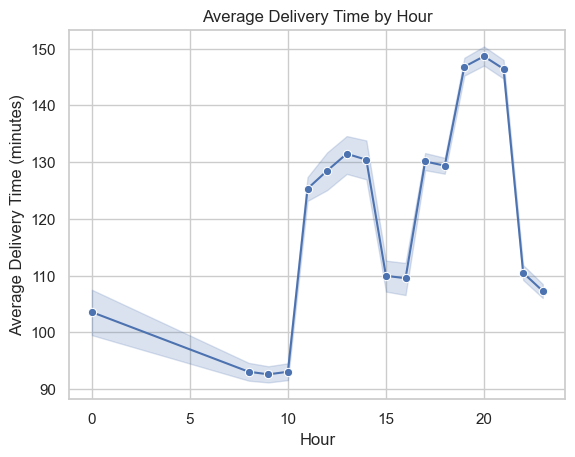

In [65]:
sns.lineplot(
    data=df,
    x="Order_Hour",
    y="Delivery_Time",
    estimator="mean",
    marker="o"
)

plt.title("Average Delivery Time by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Delivery Time (minutes)")

plt.show()

### Observation

Average delivery time varies throughout the day. Deliveries are generally faster during the morning hours, while the longest average delivery times occur in the evening (around 19:00–21:00). This pattern is consistent with increased customer demand and heavier traffic during peak hours.

In [66]:
df.groupby("Order_Hour")["Delivery_Time"]\
  .agg(["mean", "median", "count"])\
  .sort_index()

,mean,median,count
Order_Hour,,,
0,103.544393,102.5,428
8,93.038738,90.0,1807
9,92.581989,90.0,1921
10,93.033401,90.0,1976
11,125.301236,130.0,1942
12,128.468927,135.0,885
13,131.452903,135.0,775
14,130.402299,135.0,783
15,109.948157,115.0,868


### Observation

The summary statistics confirm the visual pattern observed in the previous chart. Morning orders (08:00–10:00) have the shortest average delivery times (around 93 minutes), while deliveries during the evening peak (19:00–21:00) require the most time (approximately 147–149 minutes). The number of orders also increases substantially during the evening, suggesting that higher demand contributes to longer delivery durations.

## Delivery Time by Day of Week

Next, we analyze whether delivery performance changes across different days of the week. This helps determine if certain days experience longer delivery times due to higher demand or operational factors.

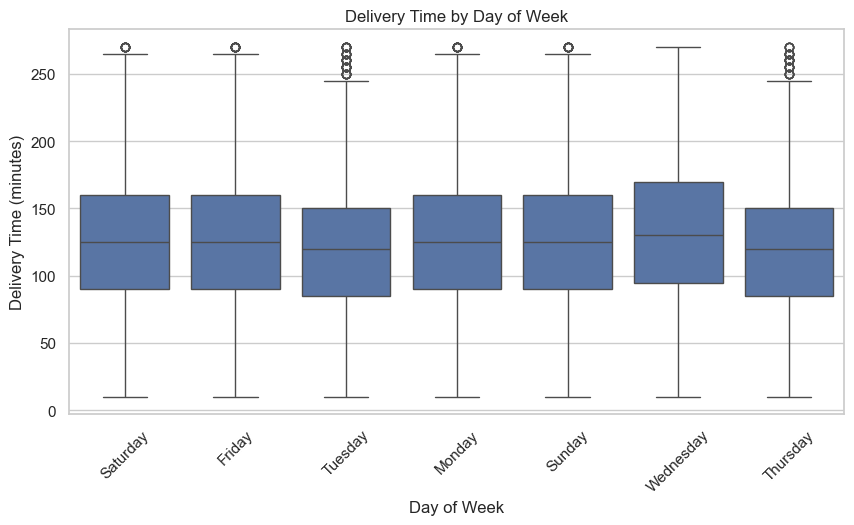

In [67]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Day_of_Week",
    y="Delivery_Time"
)

plt.xticks(rotation=45)

plt.title("Delivery Time by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delivery Time (minutes)")

plt.show()

### Observation

Delivery times remain relatively consistent across the week. While slight differences exist, no day shows a dramatically higher or lower median delivery time. Wednesday appears to have a slightly higher median delivery time, but the overall distributions are similar, suggesting that the day of the week has only a limited effect on delivery performance.

In [68]:
df.groupby("Day_of_Week")["Delivery_Time"]\
  .agg(["mean","median","count"])\
  .sort_values("mean", ascending=False)

,mean,median,count
Day_of_Week,,,
Wednesday,131.715847,130.0,6771
Friday,126.942844,125.0,6701
Sunday,124.971659,125.0,5963
Saturday,124.956261,125.0,6013
Monday,124.816695,125.0,5930
Tuesday,120.339620,120.0,6045
Thursday,119.790740,120.0,6069


### Observation

The grouped statistics support the findings from the boxplot. Wednesday has the highest average delivery time (approximately 132 minutes), while Thursday and Tuesday have the lowest averages (around 120 minutes). However, the differences between days are relatively small, indicating that the day of the week has a limited influence on delivery duration compared to factors such as traffic, weather, or distance.

# Statistical Analysis

After exploring the data visually, statistical hypothesis testing is performed to determine whether the observed differences between groups are statistically significant rather than occurring by chance.

In [69]:
from scipy.stats import f_oneway

In [70]:
df["Traffic"].value_counts(dropna=False)

Traffic
Low        14940
Jam        13678
Medium     10595
High        4279
Name: count, dtype: int64

In [71]:
low = df[df["Traffic"] == "Low"]["Delivery_Time"]
medium = df[df["Traffic"] == "Medium"]["Delivery_Time"]
high = df[df["Traffic"] == "High"]["Delivery_Time"]
jam = df[df["Traffic"] == "Jam"]["Delivery_Time"]

In [72]:
print("Low:", len(low))
print("Medium:", len(medium))
print("High:", len(high))
print("Jam:", len(jam))

Low: 0
Medium: 0
High: 0
Jam: 0


In [73]:
df["Traffic"] = df["Traffic"].str.strip()

In [74]:
df["Traffic"].unique()

<StringArray>
['High', 'Jam', 'Low', 'Medium']
Length: 4, dtype: str

In [75]:
low = df[df["Traffic"] == "Low"]["Delivery_Time"]
medium = df[df["Traffic"] == "Medium"]["Delivery_Time"]
high = df[df["Traffic"] == "High"]["Delivery_Time"]
jam = df[df["Traffic"] == "Jam"]["Delivery_Time"]

In [76]:
print("Low:", len(low))
print("Medium:", len(medium))
print("High:", len(high))
print("Jam:", len(jam))

Low: 14940
Medium: 10595
High: 4279
Jam: 13678


In [77]:
f_stat, p_value = f_oneway(low, medium, high, jam)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 2216.8463833161272
P-value: 0.0


In [78]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Traffic has a statistically significant effect on Delivery Time.")
else:
    print("Fail to Reject H0")

Reject H0
Traffic has a statistically significant effect on Delivery Time.


### ANOVA Result: Traffic

The one-way ANOVA test produced a very small p-value (p < 0.05), indicating that the average delivery time differs significantly across traffic conditions. Therefore, the null hypothesis is rejected.

This confirms that traffic congestion has a statistically significant impact on delivery performance and should be considered an important factor when predicting delivery time.

In [79]:
sunny = df[df["Weather"] == "Sunny"]["Delivery_Time"]
cloudy = df[df["Weather"] == "Cloudy"]["Delivery_Time"]
fog = df[df["Weather"] == "Fog"]["Delivery_Time"]
stormy = df[df["Weather"] == "Stormy"]["Delivery_Time"]
windy = df[df["Weather"] == "Windy"]["Delivery_Time"]
sandstorms = df[df["Weather"] == "Sandstorms"]["Delivery_Time"]

In [80]:
f_stat, p_value = f_oneway(
    sunny,
    cloudy,
    fog,
    stormy,
    windy,
    sandstorms
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 432.03629634244544
P-value: 0.0


In [81]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Weather has a statistically significant effect on Delivery Time.")
else:
    print("Fail to Reject H0")

Reject H0
Weather has a statistically significant effect on Delivery Time.


In [82]:
motorcycle = df[df["Vehicle"] == "motorcycle"]["Delivery_Time"]
scooter = df[df["Vehicle"] == "scooter"]["Delivery_Time"]
van = df[df["Vehicle"] == "van"]["Delivery_Time"]
bicycle = df[df["Vehicle"] == "bicycle"]["Delivery_Time"]

In [83]:
print("Motorcycle:", len(motorcycle))
print("Scooter:", len(scooter))
print("Van:", len(van))
print("Bicycle:", len(bicycle))

Motorcycle: 0
Scooter: 0
Van: 3508
Bicycle: 0


In [84]:
df["Vehicle"].value_counts(dropna=False)

Vehicle
motorcycle     25423
scooter        14561
van             3508
Name: count, dtype: int64

In [85]:
df["Vehicle"].unique()

<StringArray>
['motorcycle ', 'scooter ', 'van']
Length: 3, dtype: str

In [86]:
df["Vehicle"] = df["Vehicle"].str.strip().str.lower()

In [87]:
df["Vehicle"].unique()

<StringArray>
['motorcycle', 'scooter', 'van']
Length: 3, dtype: str

In [88]:
motorcycle = df[df["Vehicle"] == "motorcycle"]["Delivery_Time"]
scooter = df[df["Vehicle"] == "scooter"]["Delivery_Time"]
van = df[df["Vehicle"] == "van"]["Delivery_Time"]

In [89]:
print("Motorcycle:", len(motorcycle))
print("Scooter:", len(scooter))
print("Van:", len(van))

Motorcycle: 25423
Scooter: 14561
Van: 3508


In [90]:
f_stat, p_value = f_oneway(
    motorcycle,
    scooter,
    van
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 431.74754417155975
P-value: 2.1461067258008624e-186


In [91]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Vehicle type has a statistically significant effect on Delivery Time.")
else:
    print("Fail to Reject H0")

Reject H0
Vehicle type has a statistically significant effect on Delivery Time.


### ANOVA Result: Vehicle

The one-way ANOVA test shows a statistically significant difference in delivery time between vehicle types (p < 0.05). Therefore, the null hypothesis is rejected.

This indicates that vehicle type has a meaningful impact on delivery performance.

# Machine Learning

## Delivery Time Prediction using Random Forest

In this section, a Random Forest Regressor model is built to predict delivery time based on operational, environmental, and delivery-related features.

The categorical variables are encoded using LabelEncoder, the dataset is split into training and testing sets, and the model is trained to evaluate its predictive performance.

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [93]:
df_ml = df.copy()

In [94]:
categorical_cols = [
    "Weather",
    "Traffic",
    "Vehicle",
    "Area",
    "Category",
    "Day_of_Week",
    "Month"
]

encoder = LabelEncoder()

for col in categorical_cols:
    df_ml[col] = encoder.fit_transform(df_ml[col])

In [95]:
features = [
    "Agent_Age",
    "Agent_Rating",
    "Weather",
    "Traffic",
    "Vehicle",
    "Area",
    "Category",
    "Order_Hour",
    "Preparation_Time",
    "Distance_km"
]

X = df_ml[features]
y = df_ml["Delivery_Time"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [97]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Feature Importance

After training the Random Forest model, feature importance is analyzed to determine which variables contribute the most to predicting delivery time.

The results show that **Category**, **Agent Rating**, **Weather**, and **Distance** are the most influential predictors. Variables such as **Preparation Time** and **Area** have relatively low importance, indicating a smaller contribution to the model's predictions.

In [98]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,Category,0.277264
1,Agent_Rating,0.172568
2,Weather,0.149460
9,Distance_km,0.130981
0,Agent_Age,0.088218
3,Traffic,0.069884
7,Order_Hour,0.063054
4,Vehicle,0.026318
8,Preparation_Time,0.012014
5,Area,0.010238


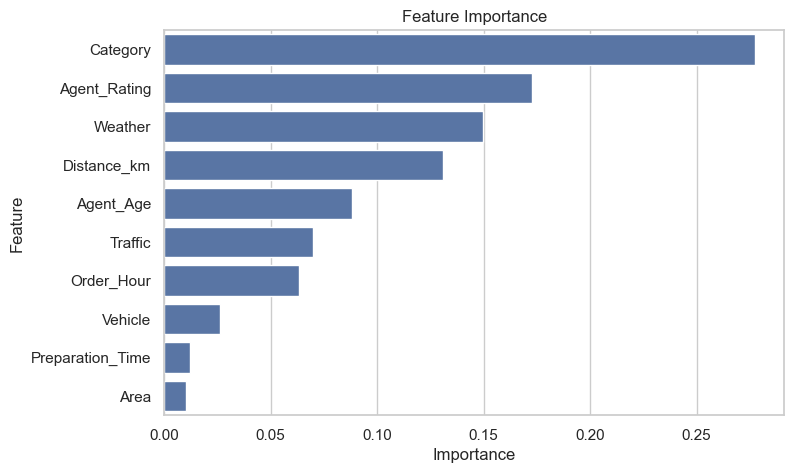

In [99]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [101]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 2.01,-39.22, -5. ,..., -0.13, -0.04, 2.58]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Agent_Age','Agent_Rating','Weather',...,'Order_Hour','Preparation_Time', 'Distance_km']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,256.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [102]:
y_pred_lr = lr.predict(X_test)

In [103]:
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2: 0.29133113709464264
MAE: 33.497040860770696
RMSE: 43.65001260981492


In [104]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [105]:
y_pred_rf = rf.predict(X_test)

In [106]:
print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2: 0.7962373827341167
MAE: 17.948374525807566
RMSE: 23.40587886171151


## Model Comparison

To evaluate predictive performance, two regression models were trained:

- Linear Regression|
- Random Forest Regressor

The models were evaluated using three metrics:

- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

The comparison helps determine which algorithm provides more accurate delivery time predictions.

In [107]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

comparison

,Model,R2,MAE,RMSE
0,Linear Regression,0.291331,33.497041,43.650013
1,Random Forest,0.796237,17.948375,23.405879


## Model Evaluation

The Random Forest model significantly outperformed Linear Regression across all evaluation metrics.

While Linear Regression explained only a small portion of the variance in delivery time (R² ≈ 0.29), Random Forest achieved a much higher predictive performance (R² ≈ 0.80).

The lower MAE and RMSE values also indicate that Random Forest produces substantially more accurate predictions. This suggests that delivery time depends on complex, non-linear relationships between operational variables, which are better captured by ensemble tree-based models.

## Visual Comparison of Models

The chart below compares the predictive performance of Linear Regression and Random Forest using the R² score.

A higher R² value indicates that the model explains a larger proportion of the variance in delivery time. The visualization clearly shows that Random Forest achieves substantially better predictive performance than Linear Regression.

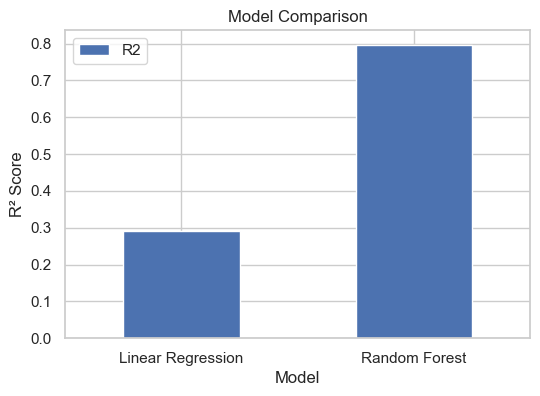

In [108]:
comparison.set_index("Model")[["R2"]].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("R² Score")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [109]:
df.to_csv("amazon_delivery_final.csv", index=False)

# Final Conclusion

This project analyzed an Amazon delivery dataset using data cleaning, exploratory data analysis (EDA), statistical testing, feature engineering, and machine learning techniques.

Key findings include:

- Traffic, weather, vehicle type, and order category significantly affect delivery time.
- Distance and agent rating are among the most important predictors.
- Feature engineering improved the quality of the analysis by creating meaningful variables such as preparation time, order hour, and delivery distance.
- Random Forest significantly outperformed Linear Regression, achieving much higher predictive accuracy.

This project demonstrates the complete workflow of a Data Analyst, from raw data preprocessing to statistical analysis, visualization, predictive modeling, and business insights.